In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import nltk
from nltk.corpus import stopwords
import re


In [5]:
import pandas as pd

df = pd.read_csv("data/spam.csv", encoding="latin-1")
df = df[['v1', 'v2']]  # Keep only the needed columns
df.columns = ['label', 'message']  # Rename columns
df.head()


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [9]:
from sklearn.model_selection import train_test_split

X = df['message']
y = df['label_num']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)


In [11]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

model = MultinomialNB()
model.fit(X_train_vec, y_train)

y_pred = model.predict(X_test_vec)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.9623318385650225
              precision    recall  f1-score   support

           0       0.96      1.00      0.98       965
           1       1.00      0.72      0.84       150

    accuracy                           0.96      1115
   macro avg       0.98      0.86      0.91      1115
weighted avg       0.96      0.96      0.96      1115



In [12]:
def predict_spam(msg):
    msg_vec = vectorizer.transform([msg])
    pred = model.predict(msg_vec)
    return "Spam" if pred[0]==1 else "Ham"

predict_spam("Congratulations! You won a free ticket.")


'Ham'

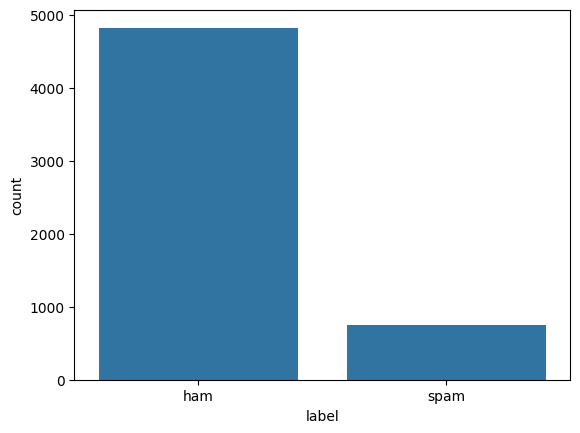

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='label', data=df)
plt.show()


In [14]:
import pickle

pickle.dump(model, open("spam_model.pkl", "wb"))
pickle.dump(vectorizer, open("vectorizer.pkl", "wb"))


In [16]:
# Example new messages
new_messages = ["Congratulations! You've won a $1000 gift card.", 
                "Hey, are we meeting today?"]

# Transform messages using your vectorizer
new_vectors = vectorizer.transform(new_messages)

# Predict using your trained model
predictions = model.predict(new_vectors)

for msg, pred in zip(new_messages, predictions):
    print(f"Message: {msg}\nPrediction: {'Spam' if pred == 1 else 'Ham'}\n")


Message: Congratulations! You've won a $1000 gift card.
Prediction: Spam

Message: Hey, are we meeting today?
Prediction: Ham

